Para construir un modelo que transforme tus predicciones de casos de dengue en una **probabilidad de epidemia**, necesitamos realizar un paso intermedio crucial: **definir matemáticamente qué es una epidemia**.

En epidemiología, una epidemia no se define al azar. Por lo general, se establece mediante un **umbral histórico** (por ejemplo, si los casos superan el percentil 75 u 80 de los últimos años, o si cruzan la frontera del "canal endémico"). Como la regresión logística es un modelo de clasificación binaria, convertiremos tus predicciones de conteo en una variable objetivo binaria ($Y = 1$ si hay epidemia, $Y = 0$ si es un comportamiento normal).

Aquí tienes el script completo y estructurado para procesar tus series de tiempo, definir el umbral y entrenar el modelo de Regresión Logística utilizando `scikit-learn`:



CONFIGURACIÓN DEL MODELO LOGÍSTICO - CAUCASIA
-> Umbral calculado (Percentil 80): 59.00 casos semanales.
-> Semanas en estado Normal (0)   : 117
-> Semanas en estado Epidemia (1) : 33

[ÉXITO] Modelo entrenado.
-> Fórmula logística de riesgo: P(Epidemia) = 1 / (1 + e^-(-23.1987 + 0.4181 * Prediccion))

--------------------------------------------------
INFORME DE RENDIMIENTO DEL CLASIFICADOR
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        24
           1       0.83      0.83      0.83         6

    accuracy                           0.93        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.93      0.93      0.93        30

-> Área Bajo la Curva ROC (AUC): 0.9931


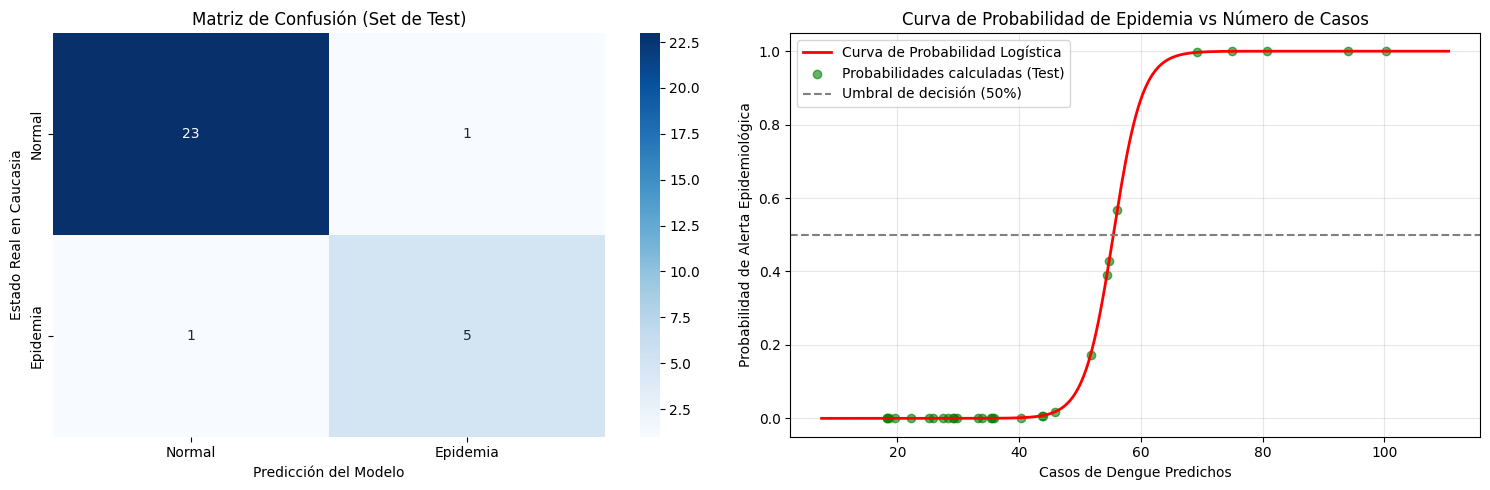

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. PREPARACIÓN DE LOS DATOS
# =============================================================================
# Nota: Reemplaza este bloque con la carga real de tus archivos o DataFrames
# Imaginemos que tienes un DataFrame llamado 'df_dengue' indexado por fecha.

# Simulamos el DataFrame que deberías tener:
# - 'casos_reales': El conteo real de dengue registrado en Caucasia.
# - 'predicciones_arimax': Las salidas de tu modelo previo para ese periodo.
np.random.seed(42)
fechas = pd.date_range(start="2023-01-01", periods=150, freq="W")
casos_reales = np.random.negative_binomial(n=5, p=0.1, size=150)  # Simulación de comportamiento epidemiológico
predicciones_arimax = casos_reales + np.random.normal(0, 3, size=150) # Simulación de la predicción con ruido
predicciones_arimax = np.clip(predicciones_arimax, 0, None) # Evitar números negativos

df_dengue = pd.DataFrame({
    "casos_reales": casos_reales,
    "predicciones_dengue": predicciones_arimax
}, index=fechas)

# =============================================================================
# 2. DEFINICIÓN DEL UMBRAL DE EPIDEMIA (ETIQUETADO BINARIO)
# =============================================================================
# Definimos el umbral basado en el histórico real (Percentil 80 como alerta epidemiológica)
UMBRAL_EPIDEMIA = df_dengue["casos_reales"].quantile(0.80)

# Creamos la variable objetivo (Y): 1 si superó el umbral, 0 si no.
df_dengue["epidemia_real"] = (df_dengue["casos_reales"] >= UMBRAL_EPIDEMIA).astype(int)

print("="*75)
print(f"CONFIGURACIÓN DEL MODELO LOGÍSTICO - CAUCASIA")
print("="*75)
print(f"-> Umbral calculado (Percentil 80): {UMBRAL_EPIDEMIA:.2f} casos semanales.")
print(f"-> Semanas en estado Normal (0)   : {df_dengue['epidemia_real'].value_counts()[0]}")
print(f"-> Semanas en estado Epidemia (1) : {df_dengue['epidemia_real'].value_counts()[1]}\n")

# =============================================================================
# 3. SEGMENTACIÓN DE DATOS (TRAIN / TEST)
# =============================================================================
# X: Las predicciones del número de casos (puedes incluir rezagos si lo deseas)
X = df_dengue[["predicciones_dengue"]] 
y = df_dengue["epidemia_real"]

# Al ser una serie de tiempo, usamos un corte cronológico en lugar de aleatorio
# Entrenamos con el primer 80% del tiempo y testeamos con el 20% final.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

# =============================================================================
# 4. ENTRENAMIENTO DE LA REGRESIÓN LOGÍSTICA
# =============================================================================
modelo_logistico = LogisticRegression(class_weight='balanced') # 'balanced' ayuda si hay pocas epidemias
modelo_logistico.fit(X_train, y_train)

# Predicciones de clases (0 o 1)
y_pred_class = modelo_logistico.predict(X_test)

# Predicciones de PROBABILIDAD (Entrega una matriz [prob_0, prob_1], nos interesa la prob de epidemia: columna 1)
y_pred_prob = modelo_logistico.predict_proba(X_test)[:, 1]

# Extraemos la ecuación matemática del modelo para Caucasia
beta_0 = modelo_logistico.intercept_[0]
beta_1 = modelo_logistico.coef_[0][0]

print(f"[ÉXITO] Modelo entrenado.")
print(f"-> Fórmula logística de riesgo: P(Epidemia) = 1 / (1 + e^-({beta_0:.4f} + {beta_1:.4f} * Prediccion))")

# =============================================================================
# 5. EVALUACIÓN DEL MODELO Y METRICAS
# =============================================================================
print("\n" + "-"*50)
print("INFORME DE RENDIMIENTO DEL CLASIFICADOR")
print("-"*50)
print(classification_report(y_test, y_pred_class))

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"-> Área Bajo la Curva ROC (AUC): {auc_score:.4f}")

# =============================================================================
# 6. VISUALIZACIÓN DE PROBABILIDADES Y MATRIZ DE CONFUSIÓN
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Epidemia"], yticklabels=["Normal", "Epidemia"])
axes[0].set_title("Matriz de Confusión (Set de Test)")
axes[0].set_xlabel("Predicción del Modelo")
axes[0].set_ylabel("Estado Real en Caucasia")

# Gráfico 2: Curva de Probabilidad Logística Estimada
X_curva = np.linspace(df_dengue["predicciones_dengue"].min(), df_dengue["predicciones_dengue"].max(), 300)
# Calculamos la sigmoide manualmente para la visualización
Y_curva = 1 / (1 + np.exp(-(beta_0 + beta_1 * X_curva)))

axes[1].plot(X_curva, Y_curva, color="red", label="Curva de Probabilidad Logística", linewidth=2)
axes[1].scatter(X_test, y_test_prob := y_pred_prob, color="green", alpha=0.6, label="Probabilidades calculadas (Test)")
axes[1].axhline(0.5, color='gray', linestyle='--', label='Umbral de decisión (50%)')
axes[1].set_title("Curva de Probabilidad de Epidemia vs Número de Casos")
axes[1].set_xlabel("Casos de Dengue Predichos")
axes[1].set_ylabel("Probabilidad de Alerta Epidemiológica")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# Aspectos metodológicos clave del script:

1. **`predict_proba(X_test)[:, 1]`:** Este es el núcleo de tu solicitud. En lugar de usar `.predict()` (que te arroja fríamente un `0` o un `1`), usamos `predict_proba`. Esto extrae un valor continuo entre `0.0` y `1.0` que representa el porcentaje exacto de probabilidad de que el brote se convierta en una epidemia activa en el municipio.
2. **`class_weight='balanced'`:** Históricamente, las semanas normales son muchas más que las semanas con brotes epidémicos catastróficos. Al activar este parámetro, la regresión logística castiga con mayor dureza los errores cometidos sobre las semanas de epidemia real, obligando al modelo a no ignorar las alertas epidemiológicas tempranas.
3. **La ecuación de Riesgo para Caucasia:** El script imprime en tu consola los coeficientes $\beta_0$ (intercepto) y $\beta_1$ (pendiente). Con estos dos números, puedes aplicar la fórmula matemática en cualquier sistema informático o tablero de control en tiempo real sin necesidad de ejecutar Python en el futuro.